# <font style="color:rgb(50,120,229)">Transfer Learning and Fine-tuning </font>
In this chapter, we will learn how to fine-tune a pre-trained model for a different task than it was originally trained for.

When we train a network from scratch, we encounter the following two limitations :

- Huge data required - Since the network has millions of parameters, to get an optimal set of parameters, we need to have a lot of data.
- Huge computing power required - Even if we have a lot of data, training generally requires multiple iterations and it takes a toll on the computing resources.

The pre-trained models are trained on very large scale image classification problems. The convolutional layers act as feature extractor and the fully connected layers act as Classifiers.

Since these models are very large and have seen a huge number of images, they tend to learn very good, discriminative features. We can either use the convolutional layers merely as a feature extractor and change the last layer according to our problem or we can tweak the already trained convolutional layers to suit our problem at hand. The former approach is known as **Transfer Learning** and the latter as **Fine-tuning**.

The task of fine-tuning a network is to tweak the parameters of an already trained network so that it adapts to the new task at hand. The initial layers of a network learn very general features and as we go higher up the network, the layers tend to learn patterns more specific to the task it is being trained on. Thus, for fine-tuning, we want to keep the initial layers intact ( or freeze them ) and retrain the later layers for our task.

Thus, fine-tuning avoids both the limitations discussed above.

The amount of data required for training is not much because of two reasons. 
- First, we are not training the entire network. Second, the part that is being trained is not trained from scratch.
- Since the parameters that need to be updated is less, the amount of time needed will also be less.

As a rule of thumb, when we have a small training set and our problem is similar to the task for which the pre-trained models were trained, we can use transfer learning. If we have enough data, we can try and tweak the convolutional layers so that they learn more robust features relevant to our problem. You can get a detailed overview of Fine-tuning and transfer learning [here](http://cs231n.github.io/transfer-learning/).

In [1]:
import tensorflow as tf
print(tf.__version__)


import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
import os,shutil

2025-11-15 03:29:10.595697: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763177350.617043     105 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763177350.623683     105 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2.18.0


In [2]:
# Use only one GPU if multiple GPUs are available.
physical_devices = tf.config.list_physical_devices('GPU')
tf.config.set_visible_devices(physical_devices[0:], 'GPU')

## <font style="color:rgb(50,120,229)">Loading kaggle dataset</font>
We will be using the [kaggle dataset](https://www.kaggle.com/sriramr/apples-bananas-oranges) on fruits. The interesting thing about this dataset is that it contains 6 classes - 3 of which belong to normal fruits and 3 to rotten fruits!

To add the dataset, go to the top right corner of the window and click on `Add Data`. Click on search by url and enter the url- https://www.kaggle.com/sriramr/apples-bananas-oranges. You should be able to see the dataset. Click on the Add button. This will add the dataset to the input folder - `/kaggle/input`. You can check using the `ls` command.

In [3]:
!ls /kaggle/input/

original_data_set


In [4]:
# This folder contians all the class folders
main_path = '/kaggle/input/original_data_set/original_data_set/'

In [5]:
# all class names
classnames = os.listdir(main_path)
print(classnames)

['rottenbanana', 'freshoranges', 'rottenoranges', 'freshbanana', 'rottenapples', 'freshapples']


In [6]:
# See how many images you have per class, this helps you set the required percentage of validation data.
for each_class in classnames:
  print("Class: {}, has {} samples".format( each_class,len(os.listdir(os.path.join(main_path,each_class )))))

Class: rottenbanana, has 306 samples
Class: freshoranges, has 206 samples
Class: rottenoranges, has 222 samples
Class: freshbanana, has 218 samples
Class: rottenapples, has 328 samples
Class: freshapples, has 232 samples


## <font style="color:rgb(50,120,229)">Arrange your Data</font>
Here we are going to place the data neatly in train and validation folders inside a main folder called 'fruits' (change the name if you want), you can set the percentage of validation set. We have set it to 15%. So 15% of images from each class will go to validation folder and the rest to train folder.

In [7]:
!rm -r fruits

base_dir= 'fruits'

total_train_images = 0
total_val_images = 0

os.mkdir(base_dir)

train_dir = os.path.join(base_dir, 'train')
os.mkdir(train_dir)

validation_dir = os.path.join(base_dir, 'validation') 
os.mkdir(validation_dir)

# Set the percent of validation data you want.
validation_percent = 15

for each_class in classnames:

  source_directory = os.path.join(main_path,each_class )
  destination_train_directory = os.path.join(train_dir,each_class)
  destination_validation_directory = os.path.join(validation_dir,each_class)


  total_image_count = len(os.listdir(source_directory))

  valid_image_count = int(np.floor(total_image_count * (validation_percent/100)))

  train_images_count = int( total_image_count - valid_image_count )

  total_train_images +=  train_images_count
  total_val_images += valid_image_count

  os.mkdir(destination_train_directory)
  os.mkdir(destination_validation_directory)

  # copying the data to class's train folder
  file_names = os.listdir(source_directory)[:train_images_count]

  for fname in file_names:
      src = os.path.join(source_directory, fname)
      dst = os.path.join(destination_train_directory, fname)
      shutil.copyfile(src, dst)


  # Copying the data to class's validation folder
  file_names = os.listdir(source_directory)[train_images_count:]

  for fname in file_names:
      src = os.path.join(source_directory, fname)
      dst = os.path.join(destination_validation_directory, fname)
      shutil.copyfile(src, dst)
  
  print('total training {} images: {}'.format(each_class, len(os.listdir(destination_train_directory))))
  print('total validation {} images: {}'.format(each_class, len(os.listdir(destination_validation_directory))))

rm: cannot remove 'fruits': No such file or directory
total training rottenbanana images: 261
total validation rottenbanana images: 45
total training freshoranges images: 176
total validation freshoranges images: 30
total training rottenoranges images: 189
total validation rottenoranges images: 33
total training freshbanana images: 186
total validation freshbanana images: 32
total training rottenapples images: 279
total validation rottenapples images: 49
total training freshapples images: 198
total validation freshapples images: 34


## <font style="color:rgb(50,120,229)">Freeze the required layers</font>
In Keras, each layer has a parameter called “trainable”. For freezing the weights of a particular layer, we should set this parameter to `False`, indicating that this layer should not be trained. That’s it! We go over each layer and select which layers we want to train.

```
# Freeze the layers except the last 4 layers
for layer in vgg_conv.layers[:-4]:
    layer.trainable = False
```

## <font style="color:rgb(50,120,229)">Experiment 1: Freezing all layers - Same as Transfer Learning</font>

In [8]:
from tensorflow.keras.applications import VGG16

image_size = 224

#Load the VGG model
vgg_conv = VGG16(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))

# Freeze all the layers
for layer in vgg_conv.layers[:]:
    layer.trainable = False

# Check the trainable status of the individual layers
for layer in vgg_conv.layers:
    print(layer, layer.trainable)


from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

# Create the model
model = models.Sequential()

# Add the vgg convolutional base model
model.add(vgg_conv)

# Add new layers
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(classnames), activation='softmax'))

# Show a summary of the model. Check the number of trainable parameters
model.summary()

I0000 00:00:1763177467.369418     105 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763177467.370105     105 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
<InputLayer name=input_layer, built=True> False
<Conv2D name=block1_conv1, built=True> False
<Conv2D name=block1_conv2, built=True> False
<MaxPooling2D name=block1_pool, built=True> False
<Conv2D name=block2_conv1, built=True> False
<Conv2D name=block2_conv2, built=True> False
<MaxPooling2D name=block2_pool, built=True> False
<Conv2D name=block3_conv1, built=True> False
<Conv2D name=block3_conv2, built=True> False
<Conv2D name=block3_conv3, built=True> False
<MaxPooling2D name=block3_pool, built=True> False
<Conv2D name=block4_conv1, built=True> False
<Conv2D name=block4_conv2, built=True> False
<Conv2D name=block4_conv3, built=True> False
<MaxPooling2D name=block4_pool, built=True> False
<Conv2D name=block5_conv1, built=True> False
<Conv2D name=block5_conv2, built=True> False
<Conv2D name=block5_conv3, built=True> False
<MaxPooling2D name=block5_pool, built=True> False


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## <font style="color:rgb(50,120,229)">Setup the data generators</font>

We have already separated the data into train and validation and kept it in the “train” and “validation” folders. We can use ImageDataGenerator available in Keras to read images in batches directly from these folders and optionally perform data augmentation. We will use two different data generators for train and validation folders.

In [9]:
# No Data augmentation 
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Change the batchsize according to your system RAM
train_batchsize = 20
val_batchsize = 20

# Data Generator for Training data
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(image_size, image_size),
        batch_size=train_batchsize,
        class_mode='categorical')

# Data Generator for Validation data
validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(image_size, image_size),
        batch_size=val_batchsize,
        class_mode='categorical',
        shuffle=False)

Found 1289 images belonging to 6 classes.
Found 223 images belonging to 6 classes.


## <font style="color:rgb(50,120,229)">Train the model</font>
Till now, we have created the model and set up the data for training. So, we should proceed with the training and check out the performance. We will have to specify the optimizer and the learning rate and start training using the model.fit() function. After the training is over, we will save the model.

In [10]:
# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

# Train the Model
history = model.fit(
      train_generator,
      steps_per_epoch = int(train_generator.samples/train_generator.batch_size) ,
      epochs=20,
      validation_data=validation_generator,
      validation_steps=int(validation_generator.samples/validation_generator.batch_size),
      verbose=1)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1763177488.784249     158 service.cc:148] XLA service 0x7898140037c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763177488.785250     158 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763177488.785280     158 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763177489.137179     158 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/64 ━━━━━━━━━━━━━━━━━━━━ 11:46 11s/step - acc: 0.0500 - loss: 2.7140

I0000 00:00:1763177498.023936     158 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 224ms/step - acc: 0.4863 - loss: 1.4829 - val_acc: 0.8636 - val_loss: 0.4277
Epoch 2/20
 1/64 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - acc: 0.8500 - loss: 0.4694

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - acc: 0.8500 - loss: 0.4694 - val_acc: 0.8409 - val_loss: 0.4382
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - acc: 0.8189 - loss: 0.5041 - val_acc: 0.9273 - val_loss: 0.2719
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.9500 - loss: 0.1985 - val_acc: 0.9182 - val_loss: 0.2708
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 135ms/step - acc: 0.8935 - loss: 0.3177 - val_acc: 0.8818 - val_loss: 0.3106
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - acc: 0.8500 - loss: 0.3643 - val_acc: 0.9318 - val_loss: 0.2626
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - acc: 0.9161 - loss: 0.2391 - val_acc: 0.9227 - val_loss: 0.2514
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.9000 - loss: 0.3375 - val_acc: 0.9091 - val_loss: 0.2438
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - acc: 0.9338 - loss: 0.1903 - val_acc: 0.9455 - val_loss: 0.2314
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - acc: 0.8000 - los

## <font style="color:rgb(50,120,229)">Save the model</font>
Keras models are saved in h5 format. You can just use the save method along with the name of the file you want.


In [11]:
# Save the Model
model.save('all_freezed.keras')

In [ ]:
# If you want to download your Model run this, you can also download it from the files tab on the left
from google.colab import files
files.download('all_freezed.h5')

## <font style="color:rgb(50,120,229)">Check Performance</font>

Let us see the loss and accuracy curves.

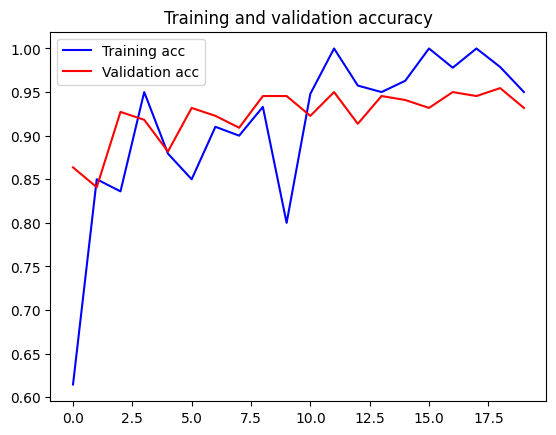

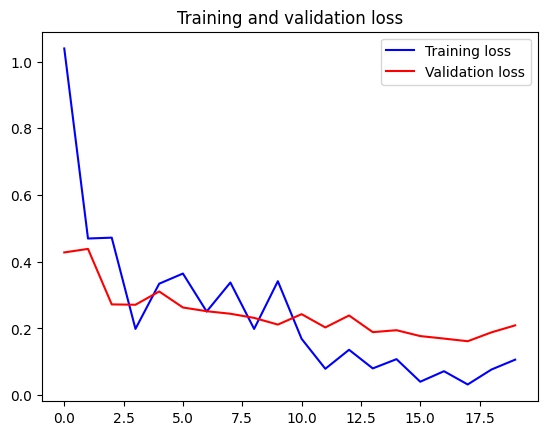

In [12]:
# Plot the accuracy and loss curves
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

## <font style="color:rgb(50,120,229)">Show the errors</font>
Also, let us visually see the errors that we got.


Found 223 images belonging to 6 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 377ms/step
No of errors = 15/223


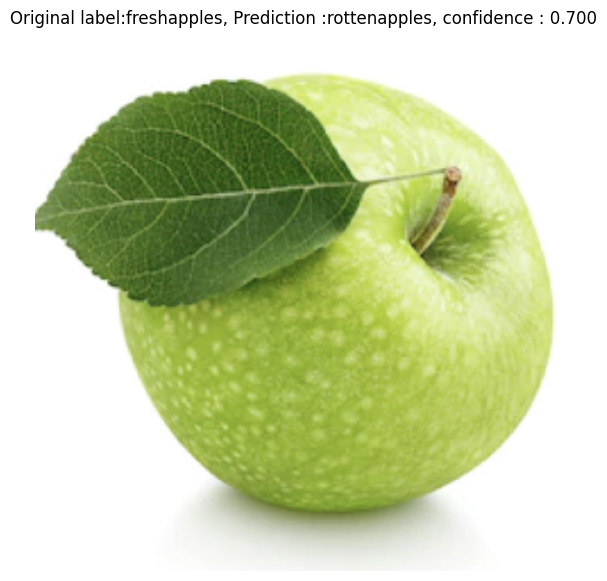

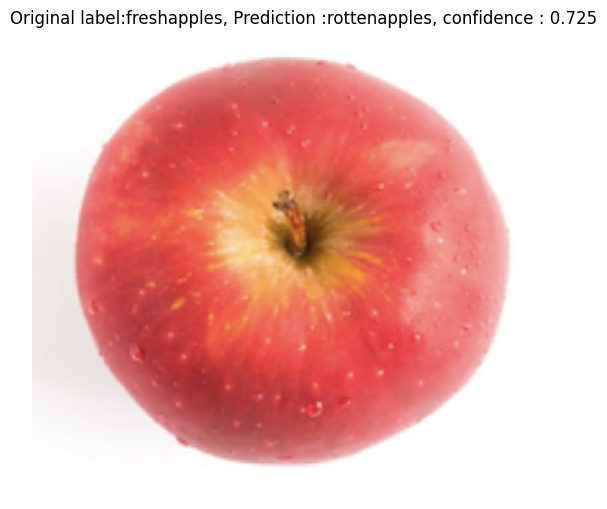

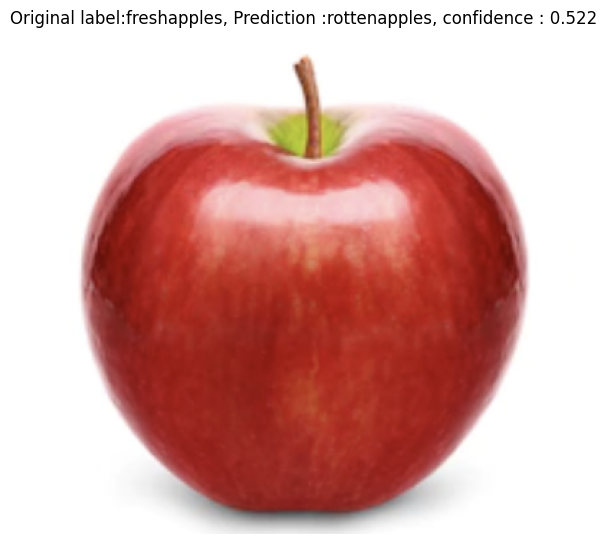

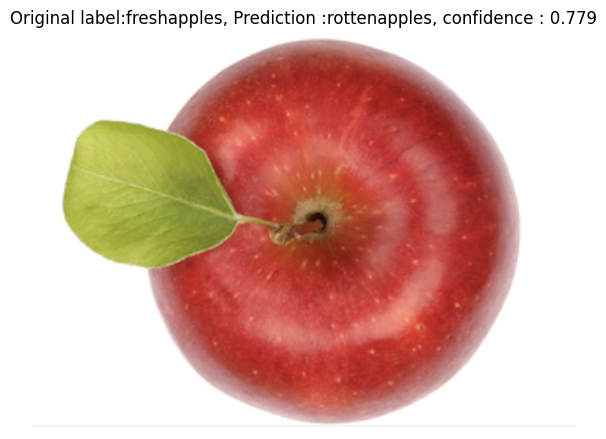

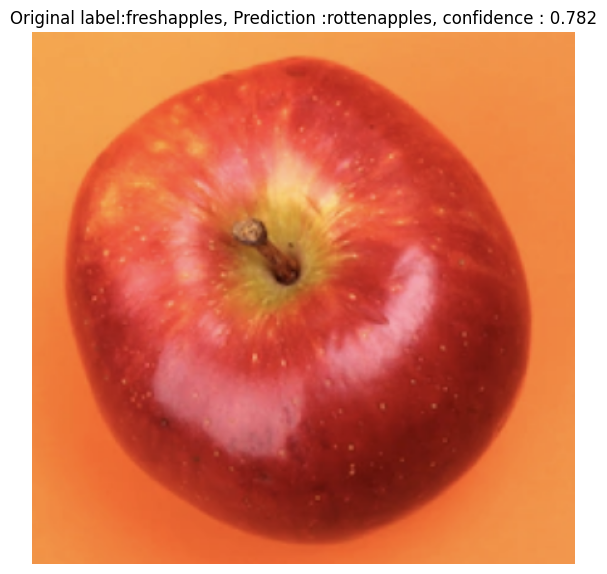

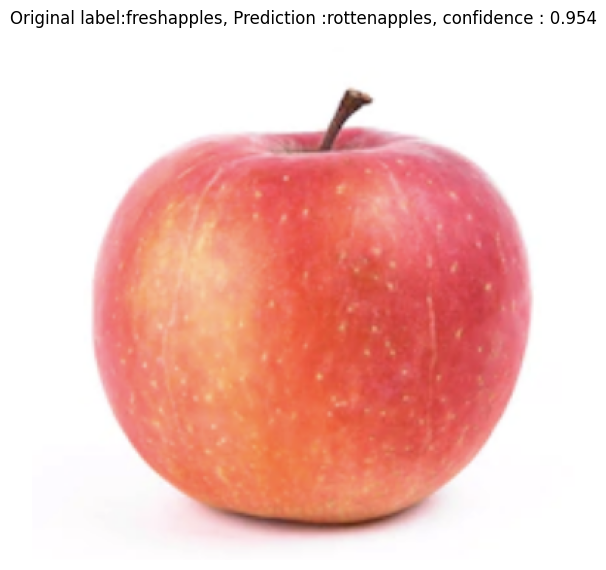

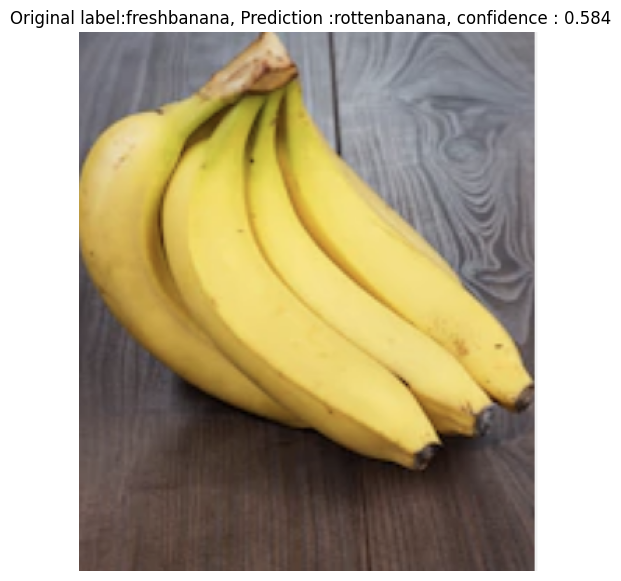

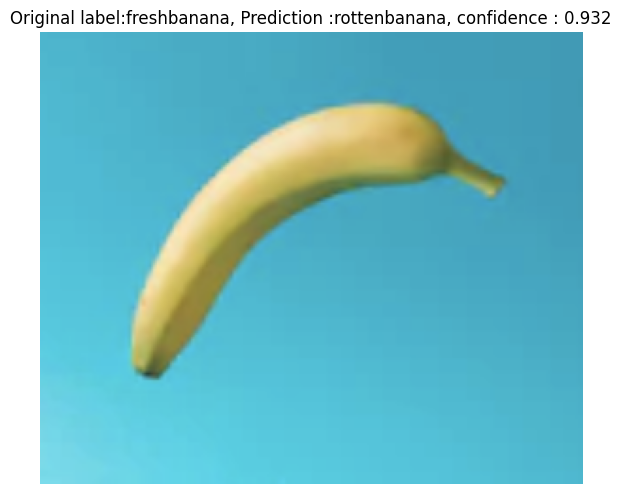

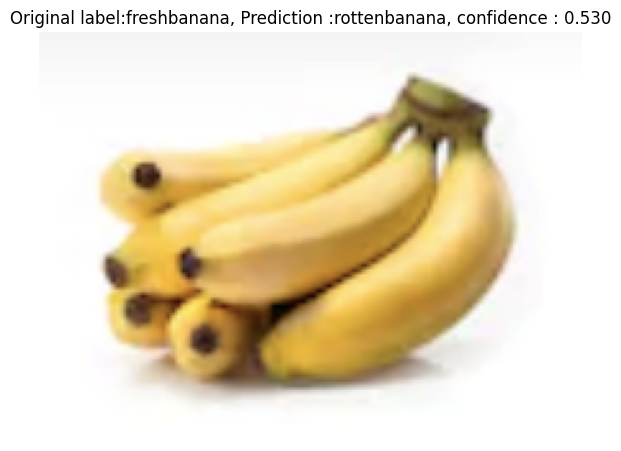

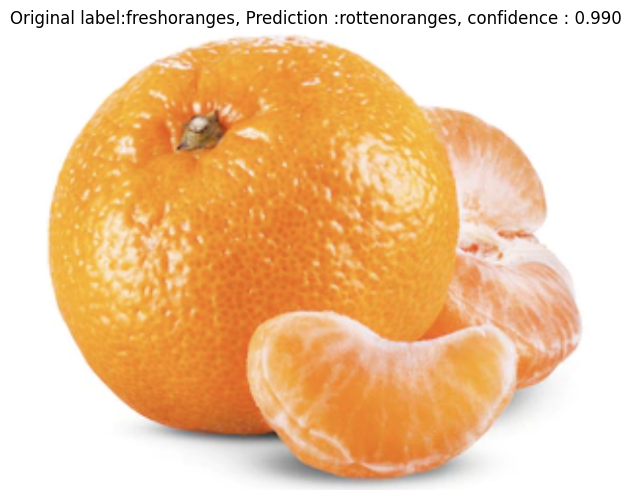

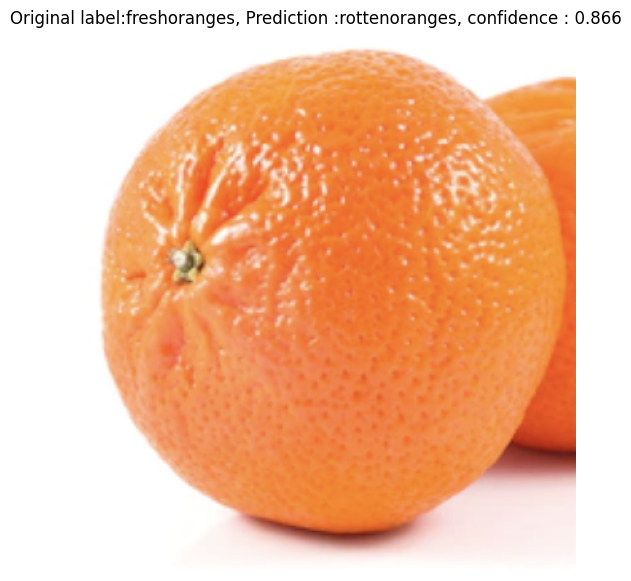

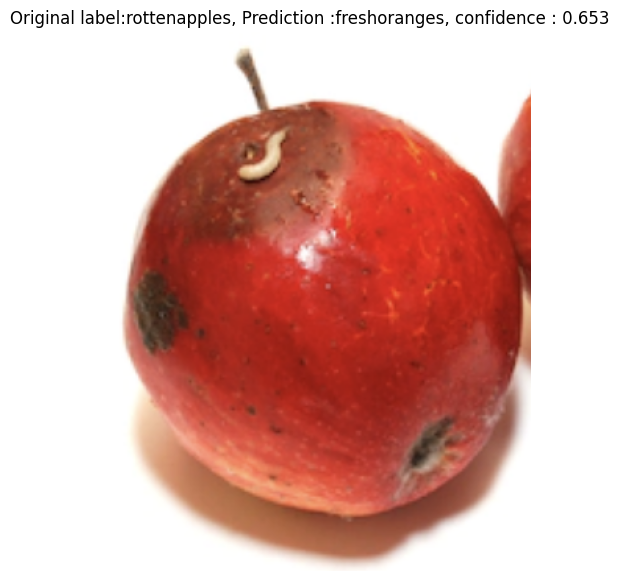

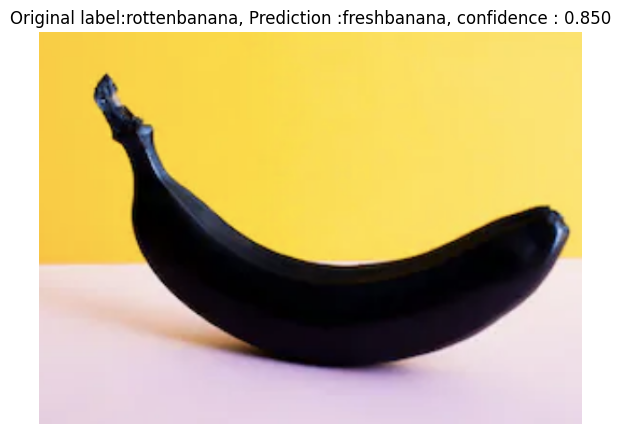

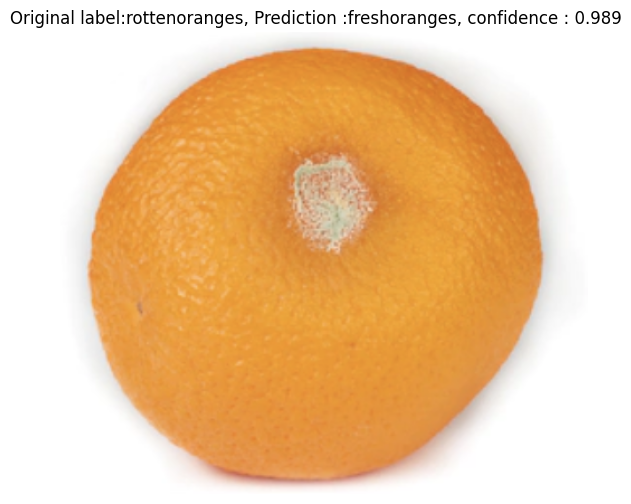

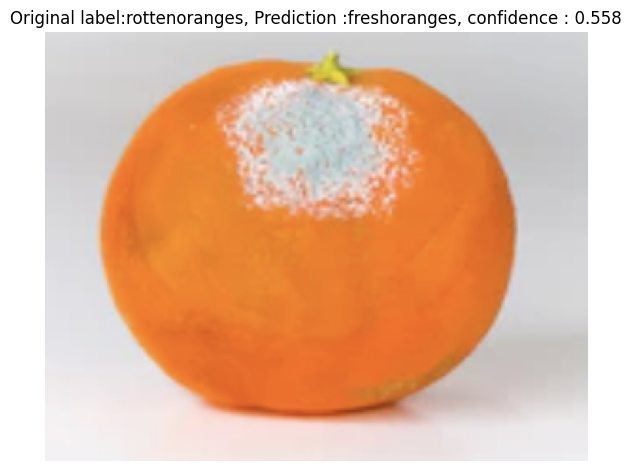

In [13]:
# Create a generator for prediction
validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(image_size, image_size),
        batch_size=val_batchsize,
        class_mode='categorical',
        shuffle=False)

# Get the filenames from the generator
fnames = validation_generator.filenames

# Get the ground truth from generator
ground_truth = validation_generator.classes

# Get the label to class mapping from the generator
label2index = validation_generator.class_indices

# Getting the mapping from class index to class label
idx2label = dict((v,k) for k,v in label2index.items())

# Get the predictions from the model using the generator
# predictions = model.predict(validation_generator, steps=validation_generator.samples/validation_generator.batch_size,verbose=1)
validation_generator.reset() # Reset generator 
predictions = model.predict(validation_generator, verbose=1)
predicted_classes = np.argmax(predictions,axis=1)

errors = np.where(predicted_classes != ground_truth)[0]
print("No of errors = {}/{}".format(len(errors),validation_generator.samples))

# Show the errors
for i in range(len(errors)):
    pred_class = np.argmax(predictions[errors[i]])
    pred_label = idx2label[pred_class]
    
    title = 'Original label:{}, Prediction :{}, confidence : {:.3f}'.format(
        fnames[errors[i]].split('/')[0],
        pred_label,
        predictions[errors[i]][pred_class])
    
    original = load_img('{}/{}'.format(validation_dir,fnames[errors[i]]))
    plt.figure(figsize=[7,7])
    plt.axis('off')
    plt.title(title)
    plt.imshow(original)
    plt.show()

We can see that the test loss is not converging even thought the training loss keeps decreasing. Let us try to train some more layers (Fine-tuning)

## <font style="color:rgb(50,120,229)">Experiment 2 : Train Last 4 layers without data augmentation</font>

In this experiment, we will keep the initial layers fixed and only retrain the last 4 layers. Since the initial layers learn more general features, it is a good practice to freeze the initial layers while fine-tuning the latter layers of the network for the new task.

In [14]:
#Load the VGG model
vgg_conv = VGG16(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))

# Freeze all layers except the last 4
for layer in vgg_conv.layers[:-4]:
    layer.trainable = False

# Check the trainable status of the individual layers
for layer in vgg_conv.layers:
    print(layer, layer.trainable)

# Create the model
model = models.Sequential()

# Add the vgg convolutional base model
model.add(vgg_conv)

# Add new layers
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(classnames), activation='softmax'))

# Show a summary of the model. Check the number of trainable parameters
model.summary()

<InputLayer name=input_layer_2, built=True> False
<Conv2D name=block1_conv1, built=True> False
<Conv2D name=block1_conv2, built=True> False
<MaxPooling2D name=block1_pool, built=True> False
<Conv2D name=block2_conv1, built=True> False
<Conv2D name=block2_conv2, built=True> False
<MaxPooling2D name=block2_pool, built=True> False
<Conv2D name=block3_conv1, built=True> False
<Conv2D name=block3_conv2, built=True> False
<Conv2D name=block3_conv3, built=True> False
<MaxPooling2D name=block3_pool, built=True> False
<Conv2D name=block4_conv1, built=True> False
<Conv2D name=block4_conv2, built=True> False
<Conv2D name=block4_conv3, built=True> False
<MaxPooling2D name=block4_pool, built=True> False
<Conv2D name=block5_conv1, built=True> True
<Conv2D name=block5_conv2, built=True> True
<Conv2D name=block5_conv3, built=True> True
<MaxPooling2D name=block5_pool, built=True> True


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 13,503,750 (51.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

## <font style="color:rgb(50,120,229)">Train the model</font>

In [15]:
# No Data augmentation 
train_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

# Change the batchsize according to your system RAM
train_batchsize = 50
val_batchsize = 20

# Data Generator for Training data
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(image_size, image_size),
        batch_size=train_batchsize,
        class_mode='categorical')

# Data Generator for Validation data
validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(image_size, image_size),
        batch_size=val_batchsize,
        class_mode='categorical',
        shuffle=False)

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

# Train the Model
history = model.fit(
      train_generator,
      steps_per_epoch=int(train_generator.samples/train_generator.batch_size) ,
      epochs=20,
      validation_data=validation_generator,
      validation_steps=int(validation_generator.samples/validation_generator.batch_size),
      verbose=1)



Found 1289 images belonging to 6 classes.
Found 223 images belonging to 6 classes.
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - acc: 0.4259 - loss: 1.6206 - val_acc: 0.8045 - val_loss: 0.4584
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - acc: 0.8400 - loss: 0.4539 - val_acc: 0.7682 - val_loss: 0.5946
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 379ms/step - acc: 0.8526 - loss: 0.4315 - val_acc: 0.8727 - val_loss: 0.2723
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - acc: 0.9400 - loss: 0.2112 - val_acc: 0.9318 - val_loss: 0.2032
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 374ms/step - acc: 0.9279 - loss: 0.2162 - val_acc: 0.9182 - val_loss: 0.1854
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.9400 - loss: 0.1685 - val_acc: 0.9409 - val_loss: 0.1839
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 379ms/step - acc: 0.9689 - loss: 0.1091 - val_acc: 0.9000 - val_loss: 0.2282
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - acc: 0.9200 - loss: 0.1837 - val_acc: 0.

In [16]:
# Save the Model
model.save('last4_layers.keras')

# you can also download the model to your pc from the files tab on the left

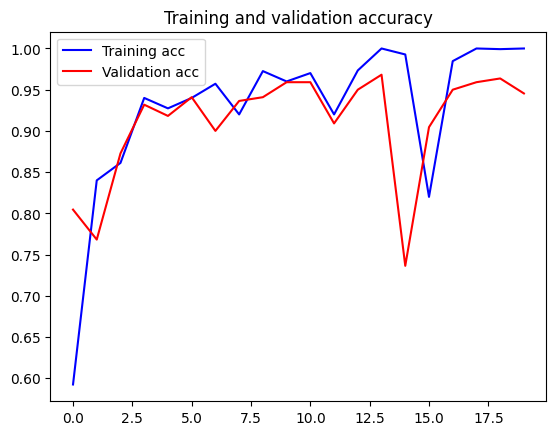

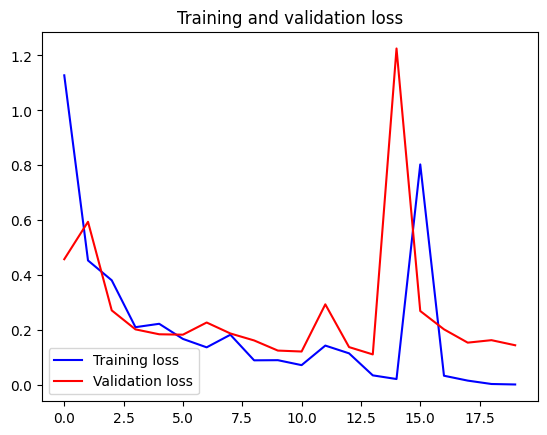

In [17]:
# Plot the accuracy and loss curves
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

## <font style="color:rgb(50,120,229)">Show the errors</font>



Found 223 images belonging to 6 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step
No of errors = 12/223


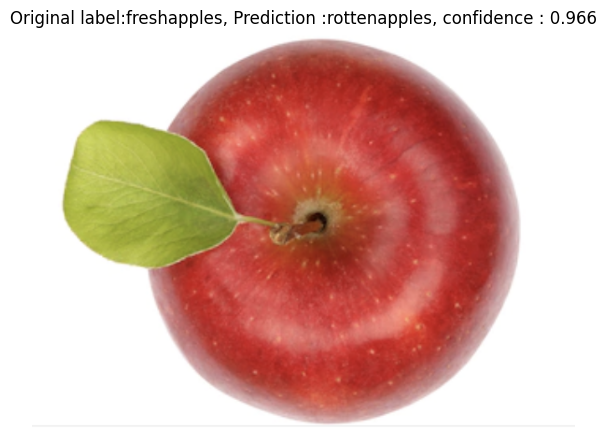

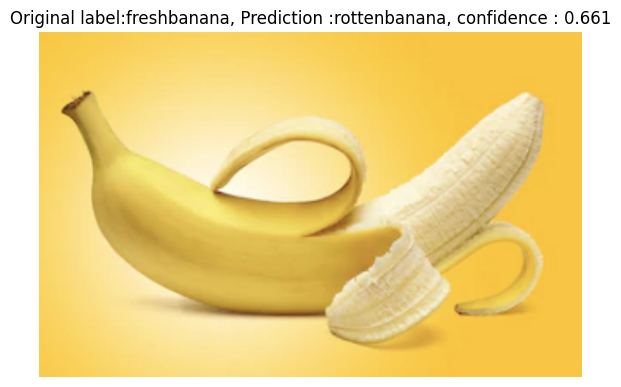

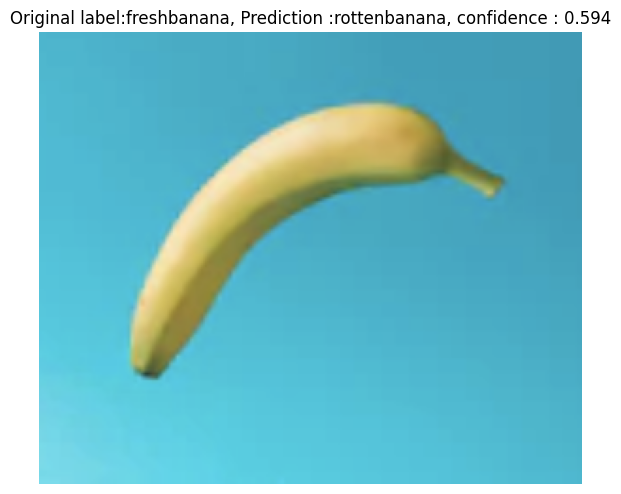

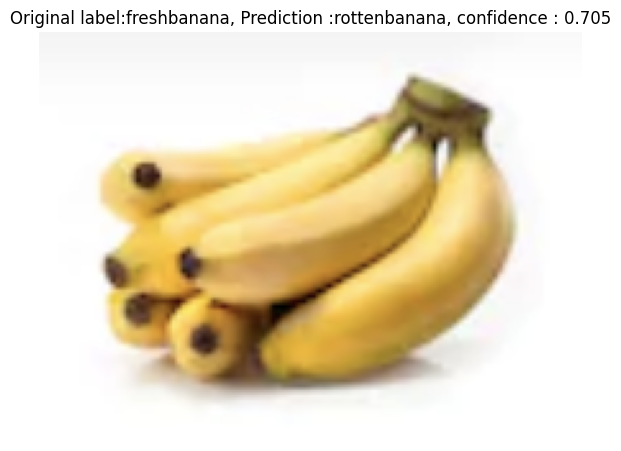

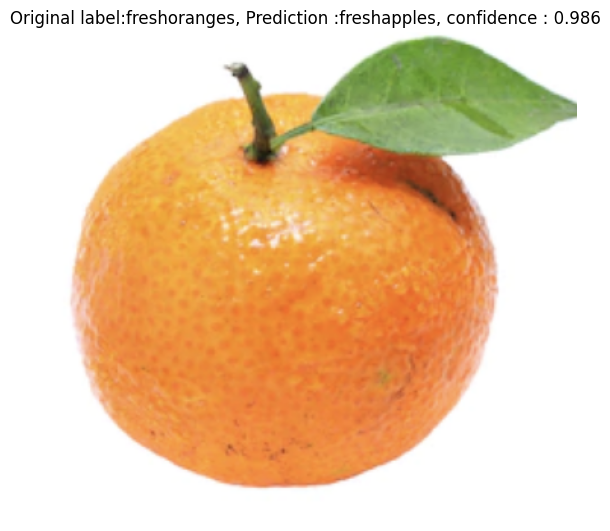

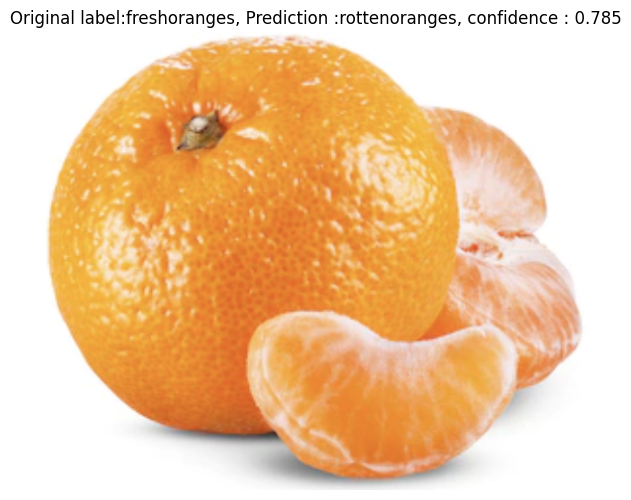

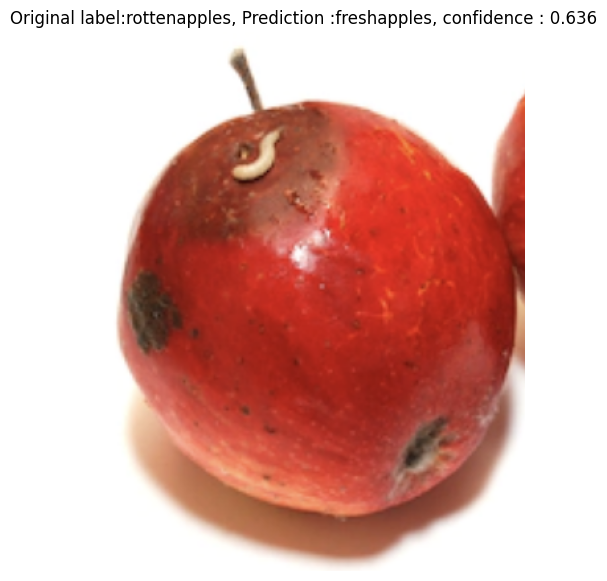

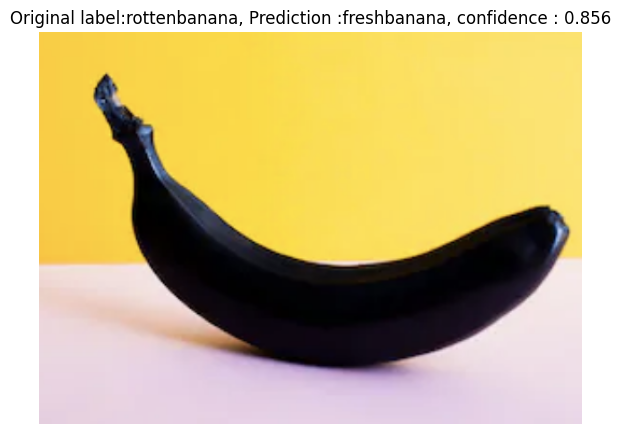

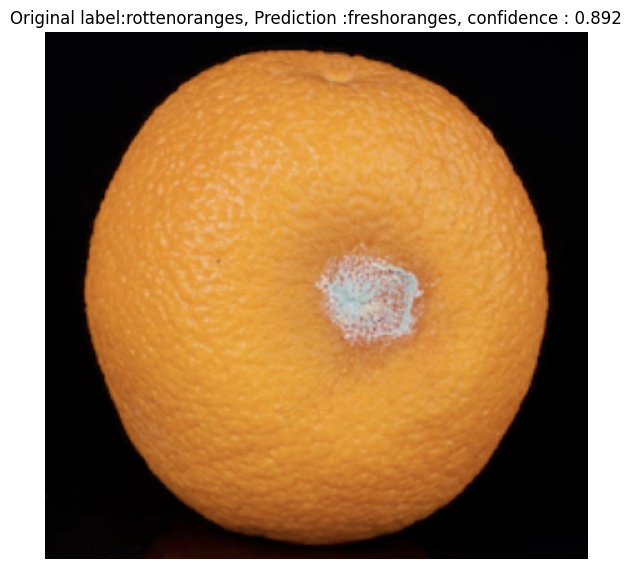

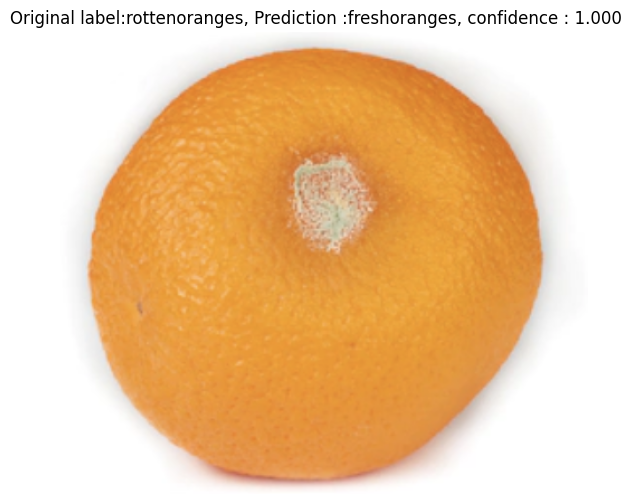

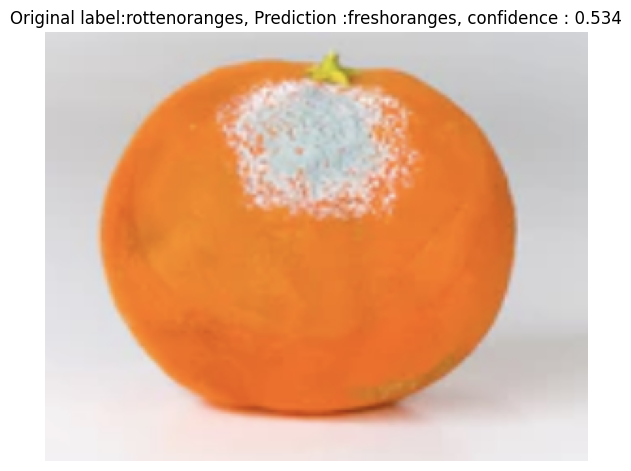

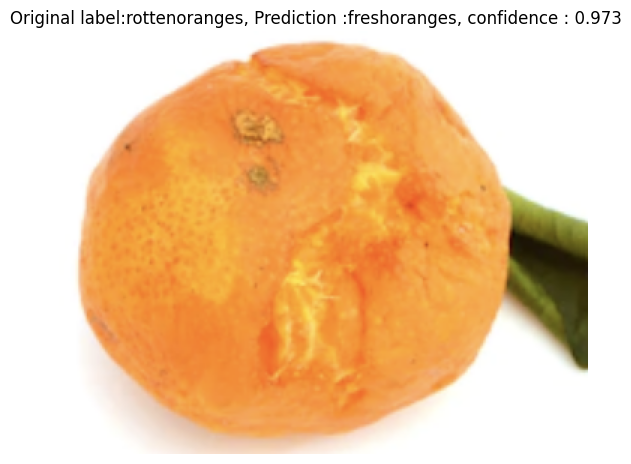

In [18]:
# Create a generator for prediction
validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(image_size, image_size),
        batch_size=val_batchsize,
        class_mode='categorical',
        shuffle=False)

# Get the filenames from the generator
fnames = validation_generator.filenames

# Get the ground truth from generator
ground_truth = validation_generator.classes

# Get the label to class mapping from the generator
label2index = validation_generator.class_indices

# Getting the mapping from class index to class label
idx2label = dict((v,k) for k,v in label2index.items())

# Get the predictions from the model using the generator
# predictions = model.predict(validation_generator, steps=validation_generator.samples/validation_generator.batch_size,verbose=1)
validation_generator.reset() # Reset generator 
predictions = model.predict(validation_generator, verbose=1)
predicted_classes = np.argmax(predictions,axis=1)

errors = np.where(predicted_classes != ground_truth)[0]
print("No of errors = {}/{}".format(len(errors),validation_generator.samples))

# Show the errors
for i in range(len(errors)):
    pred_class = np.argmax(predictions[errors[i]])
    pred_label = idx2label[pred_class]
    
    title = 'Original label:{}, Prediction :{}, confidence : {:.3f}'.format(
        fnames[errors[i]].split('/')[0],
        pred_label,
        predictions[errors[i]][pred_class])
    
    original = load_img('{}/{}'.format(validation_dir,fnames[errors[i]]))
    plt.figure(figsize=[7,7])
    plt.axis('off')
    plt.title(title)
    plt.imshow(original)
    plt.show()

## <font style="color:rgb(50,120,229)">Experiment 3 : Train last 8 layers with data augmentation</font>

We do this experiment to check if we can get even better results than the previous experiment. We train more number of layers and also use data augmentation while training.

In [19]:

#Load the VGG model
vgg_conv = VGG16(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))

# Freeze all the layers
for layer in vgg_conv.layers[:-8]:
    layer.trainable = False

# Check the trainable status of the individual layers
for layer in vgg_conv.layers:
    print(layer, layer.trainable)

# Create the model
model = models.Sequential()

# Add the vgg convolutional base model
model.add(vgg_conv)

# Add new layers
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(len(classnames), activation='softmax'))

# Show a summary of the model. Check the number of trainable parameters
model.summary()

<InputLayer name=input_layer_4, built=True> False
<Conv2D name=block1_conv1, built=True> False
<Conv2D name=block1_conv2, built=True> False
<MaxPooling2D name=block1_pool, built=True> False
<Conv2D name=block2_conv1, built=True> False
<Conv2D name=block2_conv2, built=True> False
<MaxPooling2D name=block2_pool, built=True> False
<Conv2D name=block3_conv1, built=True> False
<Conv2D name=block3_conv2, built=True> False
<Conv2D name=block3_conv3, built=True> False
<MaxPooling2D name=block3_pool, built=True> False
<Conv2D name=block4_conv1, built=True> True
<Conv2D name=block4_conv2, built=True> True
<Conv2D name=block4_conv3, built=True> True
<MaxPooling2D name=block4_pool, built=True> True
<Conv2D name=block5_conv1, built=True> True
<Conv2D name=block5_conv2, built=True> True
<Conv2D name=block5_conv3, built=True> True
<MaxPooling2D name=block5_pool, built=True> True


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 19,403,526 (74.02 MB)

 Non-trainable params: 1,735,488 (6.62 MB)

## <font style="color:rgb(50,120,229)">Train the model</font>
Here we will be using the imageDataGenerator for data augmentation.

In [20]:
train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=20,
      width_shift_range=0.2,
      height_shift_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

validation_datagen = ImageDataGenerator(rescale=1./255)

# Change the batchsize according to your system RAM
train_batchsize = 50
val_batchsize = 20

# Data Generator for Training data
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(image_size, image_size),
        batch_size=train_batchsize,
        class_mode='categorical')

# Data Generator for Validation data
validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(image_size, image_size),
        batch_size=val_batchsize,
        class_mode='categorical',
        shuffle=False)

# Compile the model
model.compile(loss='categorical_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

# Train the Model
# NOTE that we have multiplied the steps_per_epoch by 2. This is because we are using data augmentation.
history = model.fit(
      train_generator,
      steps_per_epoch=int(train_generator.samples/train_generator.batch_size),
      epochs=50,
      validation_data=validation_generator,
      validation_steps=int(validation_generator.samples/validation_generator.batch_size),
      verbose=1)

Found 1289 images belonging to 6 classes.
Found 223 images belonging to 6 classes.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - acc: 0.1740 - loss: 2.0712 - val_acc: 0.3545 - val_loss: 1.7263
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - acc: 0.2200 - loss: 1.7908 - val_acc: 0.2227 - val_loss: 1.7497
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 751ms/step - acc: 0.2573 - loss: 1.7228 - val_acc: 0.3500 - val_loss: 1.9089
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.2600 - loss: 2.0799 - val_acc: 0.4955 - val_loss: 1.4715
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 737ms/step - acc: 0.4830 - loss: 1.3283 - val_acc: 0.7636 - val_loss: 0.7235
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - acc: 0.5400 - loss: 0.9948 - val_acc: 0.7955 - val_loss: 0.6930
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 732ms/step - acc: 0.7013 - loss: 0.8535 - val_acc: 0.8227 - val_loss: 0.4598
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - acc: 0.8600 - loss: 0.4594 - val_acc: 0.

In [21]:
# Save the Model
model.save('da_last4_layers.keras')

# You can also download it from the files tab on the left

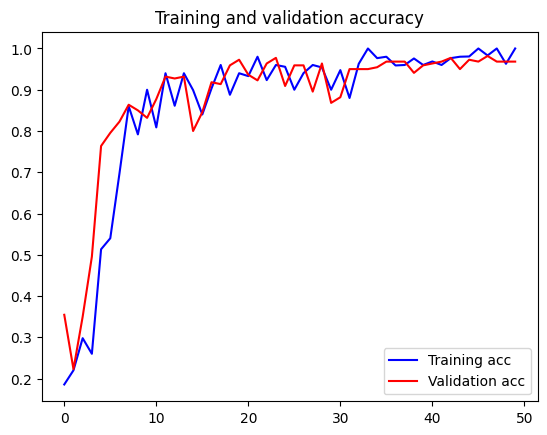

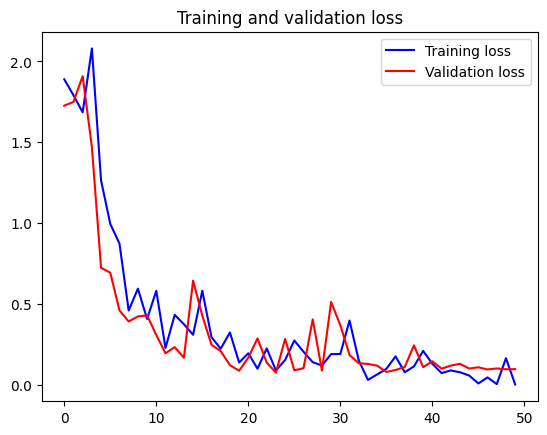

In [22]:
# Plot the accuracy and loss curves
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

## <font style="color:rgb(50,120,229)">Show the errors</font>



Found 223 images belonging to 6 classes.
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step
No of errors = 7/223


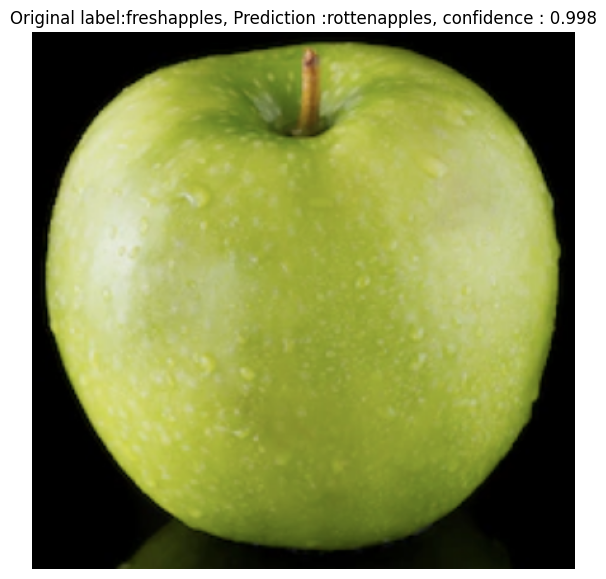

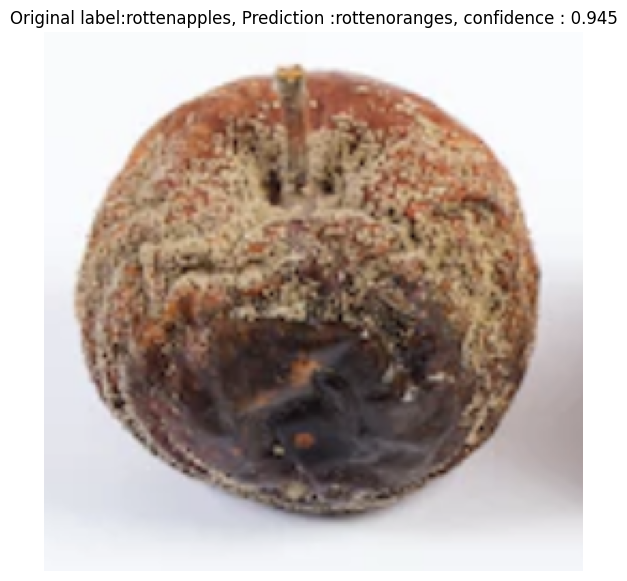

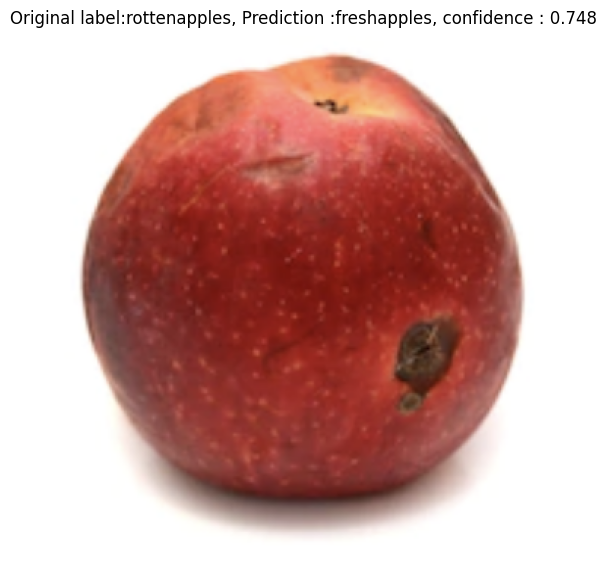

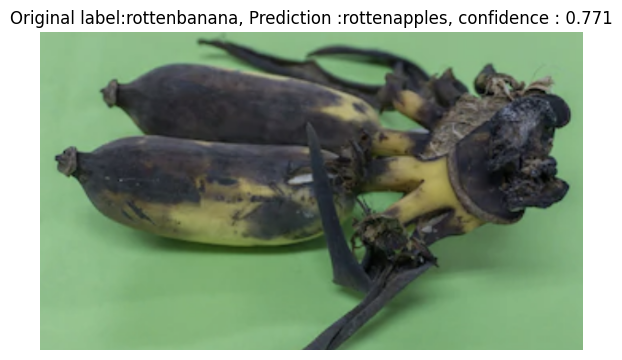

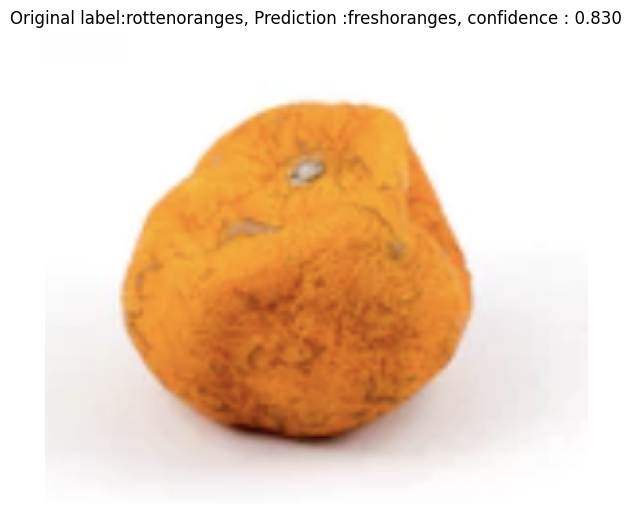

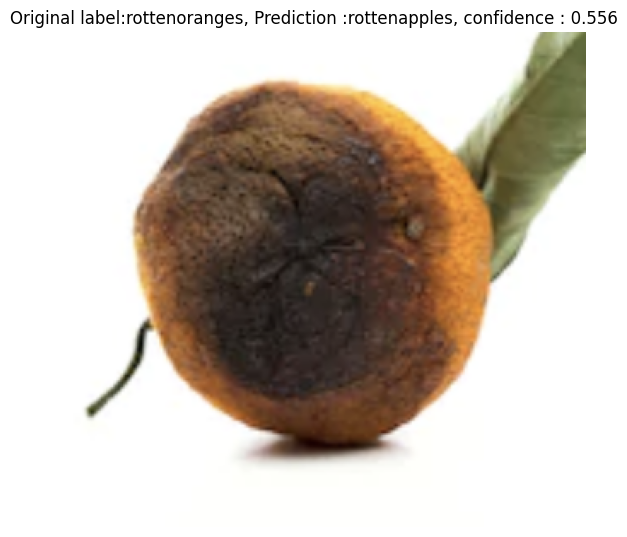

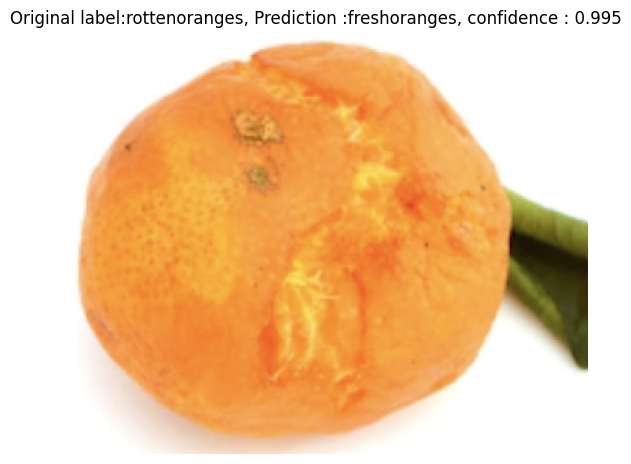

In [23]:
# Create a generator for prediction
validation_generator = validation_datagen.flow_from_directory(
        validation_dir,
        target_size=(image_size, image_size),
        batch_size=val_batchsize,
        class_mode='categorical',
        shuffle=False)

# Get the filenames from the generator
fnames = validation_generator.filenames

# Get the ground truth from generator
ground_truth = validation_generator.classes

# Get the label to class mapping from the generator
label2index = validation_generator.class_indices

# Getting the mapping from class index to class label
idx2label = dict((v,k) for k,v in label2index.items())

# Get the predictions from the model using the generator
# predictions = model.predict(validation_generator, steps=validation_generator.samples/validation_generator.batch_size,verbose=1)

validation_generator.reset() # Reset generator 
predictions = model.predict(validation_generator, verbose=1)
predicted_classes = np.argmax(predictions,axis=1)

errors = np.where(predicted_classes != ground_truth)[0]
print("No of errors = {}/{}".format(len(errors),validation_generator.samples))

# Show the errors
for i in range(len(errors)):
    pred_class = np.argmax(predictions[errors[i]])
    pred_label = idx2label[pred_class]
    
    title = 'Original label:{}, Prediction :{}, confidence : {:.3f}'.format(
        fnames[errors[i]].split('/')[0],
        pred_label,
        predictions[errors[i]][pred_class])
    
    original = load_img('{}/{}'.format(validation_dir,fnames[errors[i]]))
    plt.figure(figsize=[7,7])
    plt.axis('off')
    plt.title(title)
    plt.imshow(original)
    plt.show()

In experiment 2, there were signs of overfitting, which are reduced to an extent by using data augmentation. You should try and run for more number of epochs to see the effect of data augmentation.

## <font style="color:rgb(50,120,229)">Exercise</font>

1. Try to use a different dataset and see if the same code and network works for the new dataset.
1. Try unfreezing more layers and see how the accuracy improves.
1. Try with some different model instead of VGG